<h4>In this notbook I want to do  following steps for an Advance Price Prediction:</h4>

* [Data overview](#Over)
* [Data prepration](#Prep)
    - [Handling Outliers](#outliers)
    - [Handling Missing Data](#mis)
* [Linear Reggresion](#Lin)
* [polynomial Regression](#Pol)
* [Regularization](#Reg)
    - [Ridge](#Ridge)
    - [Lasso](#Lasso)
    - [ElasticNet](#Elas)



<h3>Import all necessary libraries</h3>

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **Import the dataset:**

In [2]:
df=pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")

<a id="Over"></a>
# Data overview

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

In [7]:
df.shape

(1460, 81)

<a id="Prep"></a>
# Data Preparation

<a id="outliers"></a>
# A- Dealing with Outliers

In [8]:
df.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

finding outliers

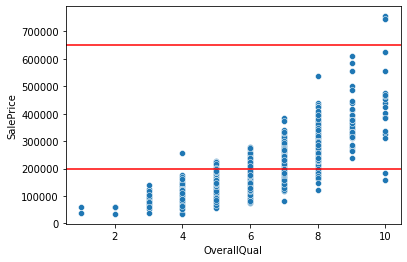

In [9]:
sns.scatterplot(data=df,x='OverallQual', y='SalePrice')
plt.axhline(y=200000,color='r')
plt.axhline(y=650000,color='r')

In [10]:
df[(df['OverallQual']>8) & (df['SalePrice']<200000)][['SalePrice', 'OverallQual']]


,SalePrice,OverallQual
523,184750,10
1298,160000,10


In [11]:
df[(df['OverallQual']>8) & (df['SalePrice']>650000)][['SalePrice', 'OverallQual']]

,SalePrice,OverallQual
691,755000,10
1182,745000,10


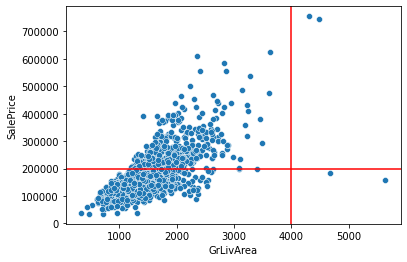

In [12]:
sns.scatterplot(data=df,x='GrLivArea', y='SalePrice')
plt.axhline(y=200000, color='r')
plt.axvline(x=4000, color='r')

In [13]:
df[(df['GrLivArea']>4000) & (df['SalePrice']>200000)][['SalePrice', 'GrLivArea']]

,SalePrice,GrLivArea
691,755000,4316
1182,745000,4476


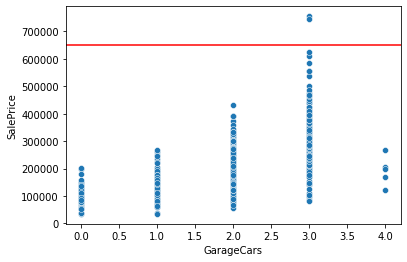

In [14]:
sns.scatterplot(data=df,x='GarageCars', y='SalePrice')
plt.axhline(y=650000, color='r')


In [15]:
df[df['SalePrice']>650000][['SalePrice', 'GarageCars']]

,SalePrice,GarageCars
691,755000,3
1182,745000,3


<b>Remove the outliers:</b>

In [16]:

index_drop=df[df['SalePrice']>650000 ].index
df=df.drop(index_drop, axis=0)
index_drop1=df[(df['OverallQual']>8) & (df['SalePrice']<200000)].index
df=df.drop(index_drop1, axis=0)

In [17]:
df.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.138849
EnclosedPorch   -0.129774
MSSubClass      -0.088160
OverallCond     -0.080202
BsmtHalfBath    -0.036792
Id              -0.027455
LowQualFinSF    -0.025351
YrSold          -0.023694
MiscVal         -0.021097
BsmtFinSF2      -0.008900
PoolArea         0.032819
3SsnPorch        0.047414
MoSold           0.056797
ScreenPorch      0.118324
BedroomAbvGr     0.160542
BsmtUnfSF        0.220678
BsmtFullBath     0.235697
LotArea          0.269866
HalfBath         0.282925
2ndFlrSF         0.297301
WoodDeckSF       0.322538
OpenPorchSF      0.330361
LotFrontage      0.356773
BsmtFinSF1       0.395923
Fireplaces       0.466765
MasVnrArea       0.478862
GarageYrBlt      0.499230
YearRemodAdd     0.521428
YearBuilt        0.535279
TotRmsAbvGrd     0.537462
FullBath         0.559048
1stFlrSF         0.625235
GarageArea       0.636964
TotalBsmtSF      0.646584
GarageCars       0.649256
GrLivArea        0.720516
OverallQual      0.800858
SalePrice        1.000000
Name: SalePr

<a id="mis"></a>
# B-Dealing with Missing Data

Cleaning the Id columns because it doesnt have important information.


In [18]:
df=df.drop('Id',axis=1)

<h3>number of missing Data in each columns:</h3>


In [19]:
df.isnull().sum().sort_values()

MSSubClass          0
TotalBsmtSF         0
Heating             0
SaleCondition       0
CentralAir          0
                 ... 
FireplaceQu       690
Fence            1176
Alley            1365
MiscFeature      1402
PoolQC           1451
Length: 80, dtype: int64

<h3>The percent of missing data in any feature:</h3>

In [20]:
100*(df.isnull().sum()/len(df)).sort_values()

MSSubClass        0.000000
TotalBsmtSF       0.000000
Heating           0.000000
SaleCondition     0.000000
CentralAir        0.000000
                   ...    
FireplaceQu      47.390110
Fence            80.769231
Alley            93.750000
MiscFeature      96.291209
PoolQC           99.656593
Length: 80, dtype: float64

<h3>Make a Function to calculate the percent of missing data in each columns (feature) and then sort it</h3>

In [21]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [22]:
nan_percent= missing_percent(df)
nan_percent

Electrical       0.068681
MasVnrType       0.549451
MasVnrArea       0.549451
BsmtQual         2.541209
BsmtCond         2.541209
BsmtFinType1     2.541209
BsmtExposure     2.609890
BsmtFinType2     2.609890
GarageCond       5.563187
GarageQual       5.563187
GarageFinish     5.563187
GarageType       5.563187
GarageYrBlt      5.563187
LotFrontage     17.788462
FireplaceQu     47.390110
Fence           80.769231
Alley           93.750000
MiscFeature     96.291209
PoolQC          99.656593
dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'MasVnrType'),
  Text(2, 0, 'MasVnrArea'),
  Text(3, 0, 'BsmtQual'),
  Text(4, 0, 'BsmtCond'),
  Text(5, 0, 'BsmtFinType1'),
  Text(6, 0, 'BsmtExposure'),
  Text(7, 0, 'BsmtFinType2'),
  Text(8, 0, 'GarageCond'),
  Text(9, 0, 'GarageQual'),
  Text(10, 0, 'GarageFinish'),
  Text(11, 0, 'GarageType'),
  Text(12, 0, 'GarageYrBlt'),
  Text(13, 0, 'LotFrontage'),
  Text(14, 0, 'FireplaceQu'),
  Text(15, 0, 'Fence'),
  Text(16, 0, 'Alley'),
  Text(17, 0, 'MiscFeature'),
  Text(18, 0, 'PoolQC')])

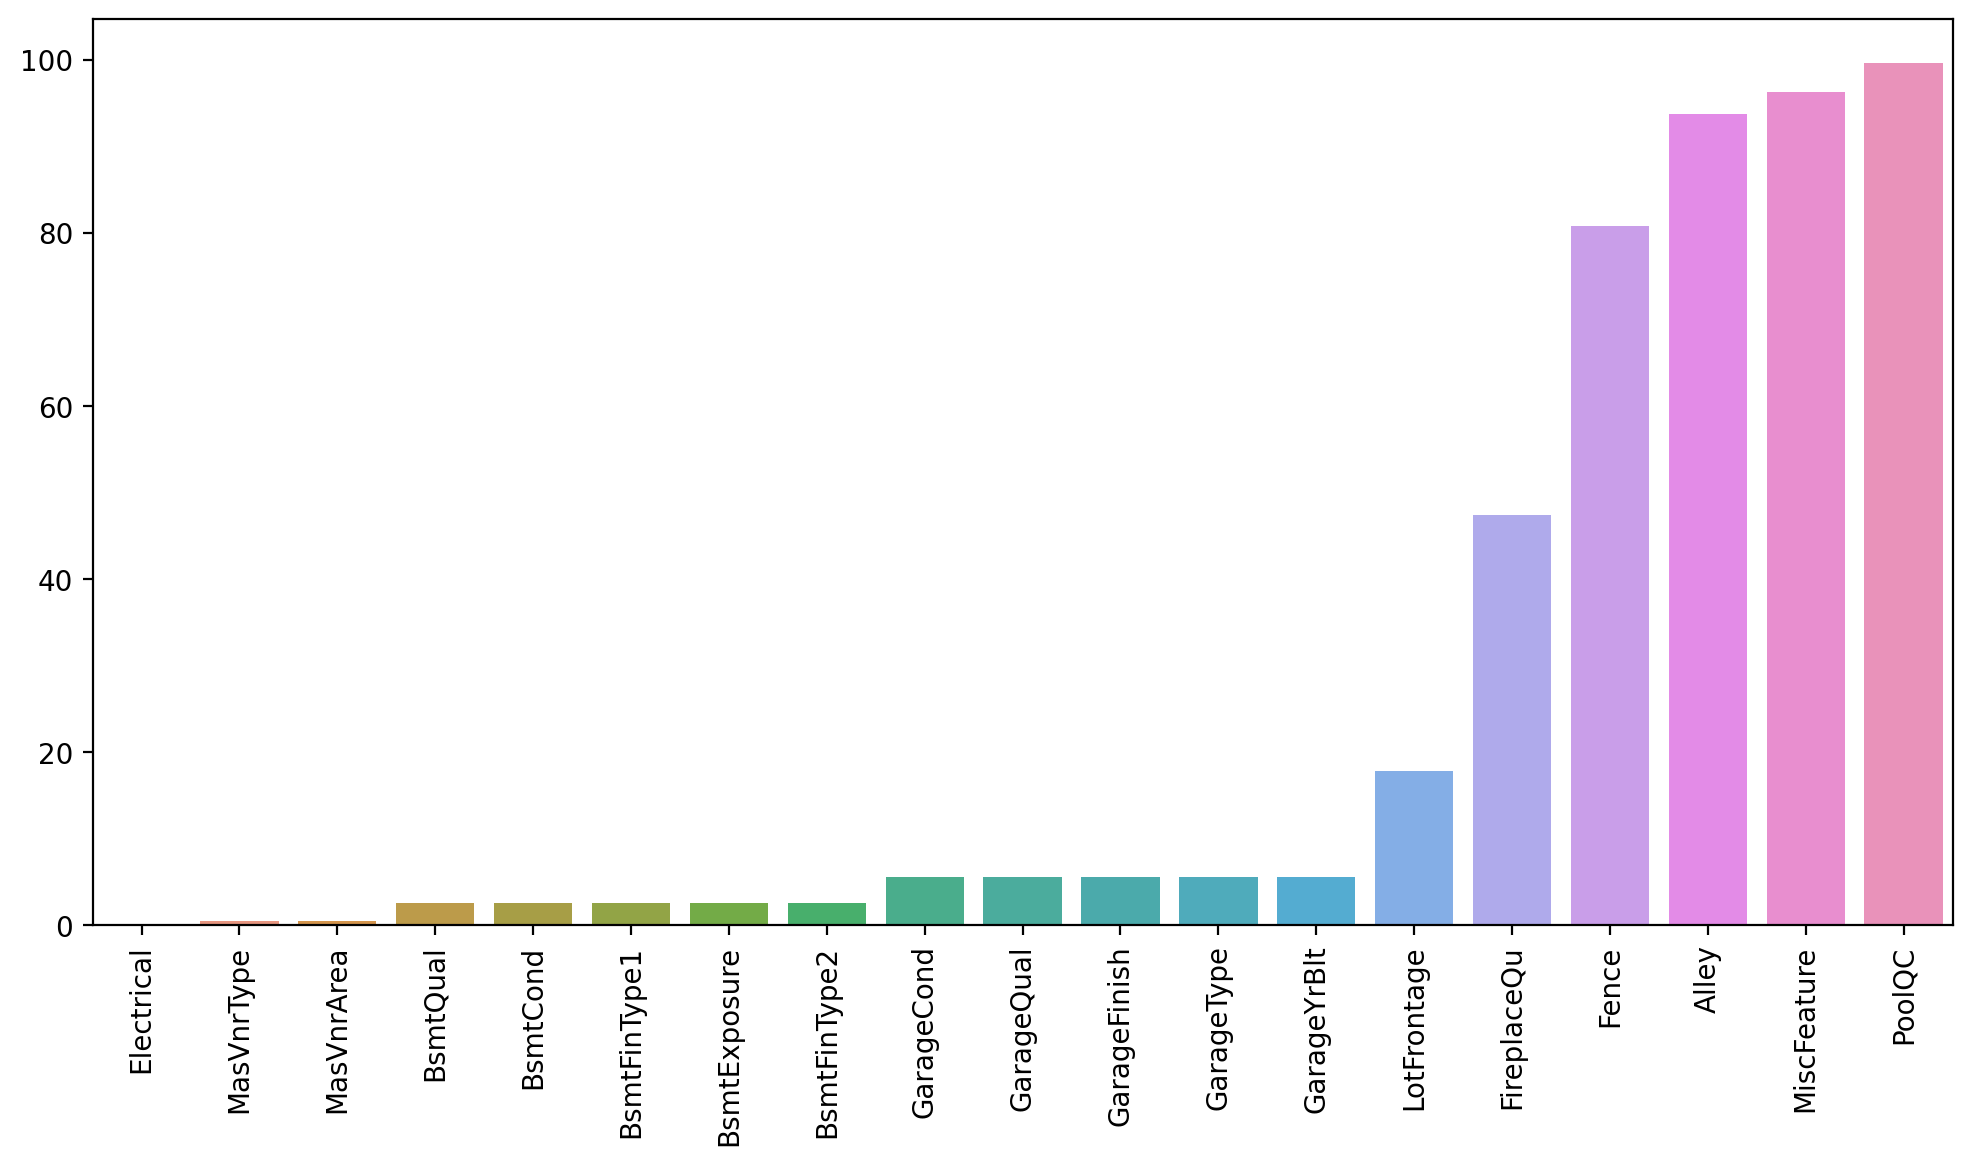

In [23]:
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

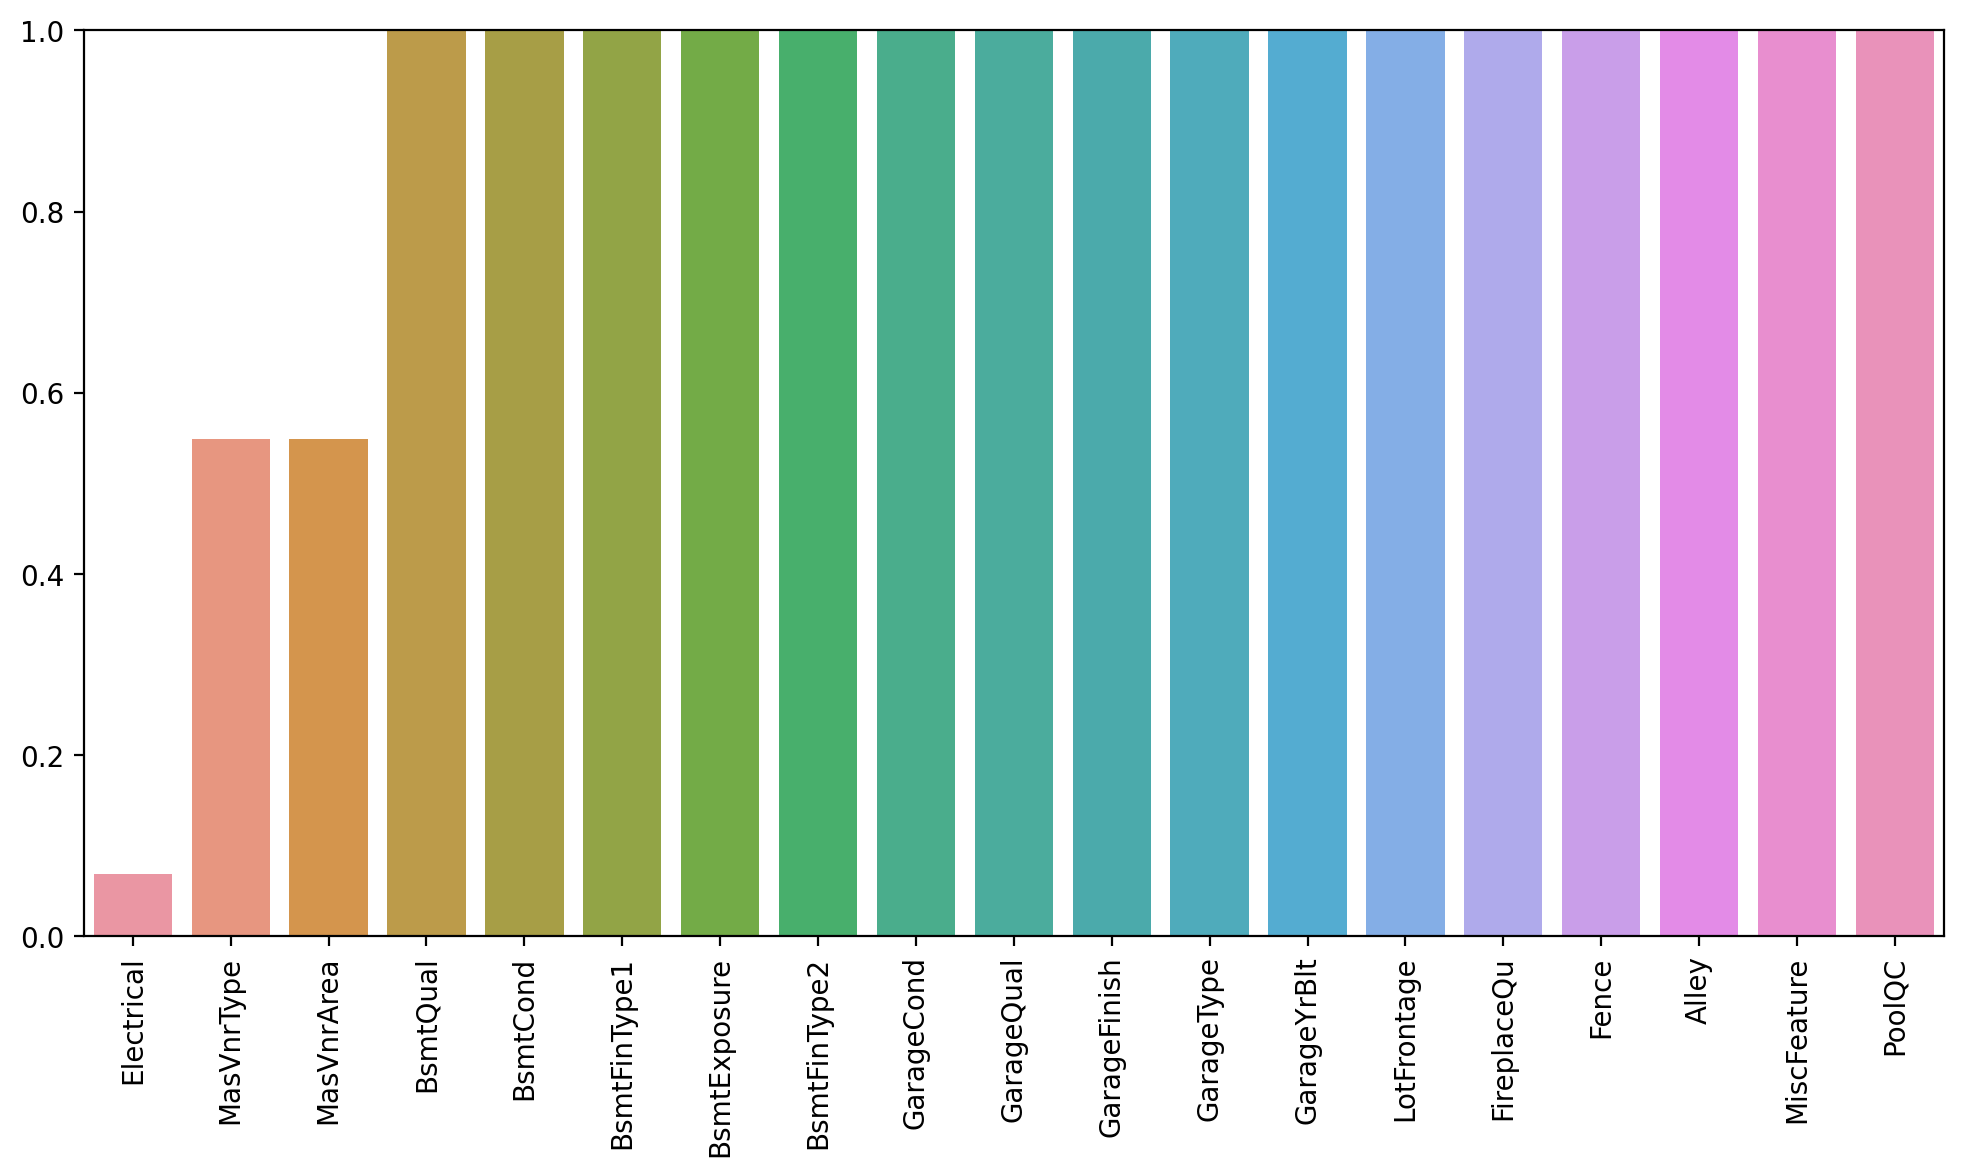

In [24]:
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)
#Set 1% threshold:
plt.ylim(0,1)

In [25]:
#columns with missing Data under 1%:
nan_percent[nan_percent<1]

Electrical    0.068681
MasVnrType    0.549451
MasVnrArea    0.549451
dtype: float64

In [26]:
100/len(df)

0.06868131868131869

It shows Electrical has got just 1 row missing Data.

<h3>The index of a row with missing Data of Electrical:</h3>

In [27]:
df[df['Electrical'].isnull()]['Electrical']

1379    NaN
Name: Electrical, dtype: object

<h3>removing the row with missing Data of Electrical:
</h3>

In [28]:
df=df.dropna(axis=0, subset=['Electrical'])

(0.0, 1.0)

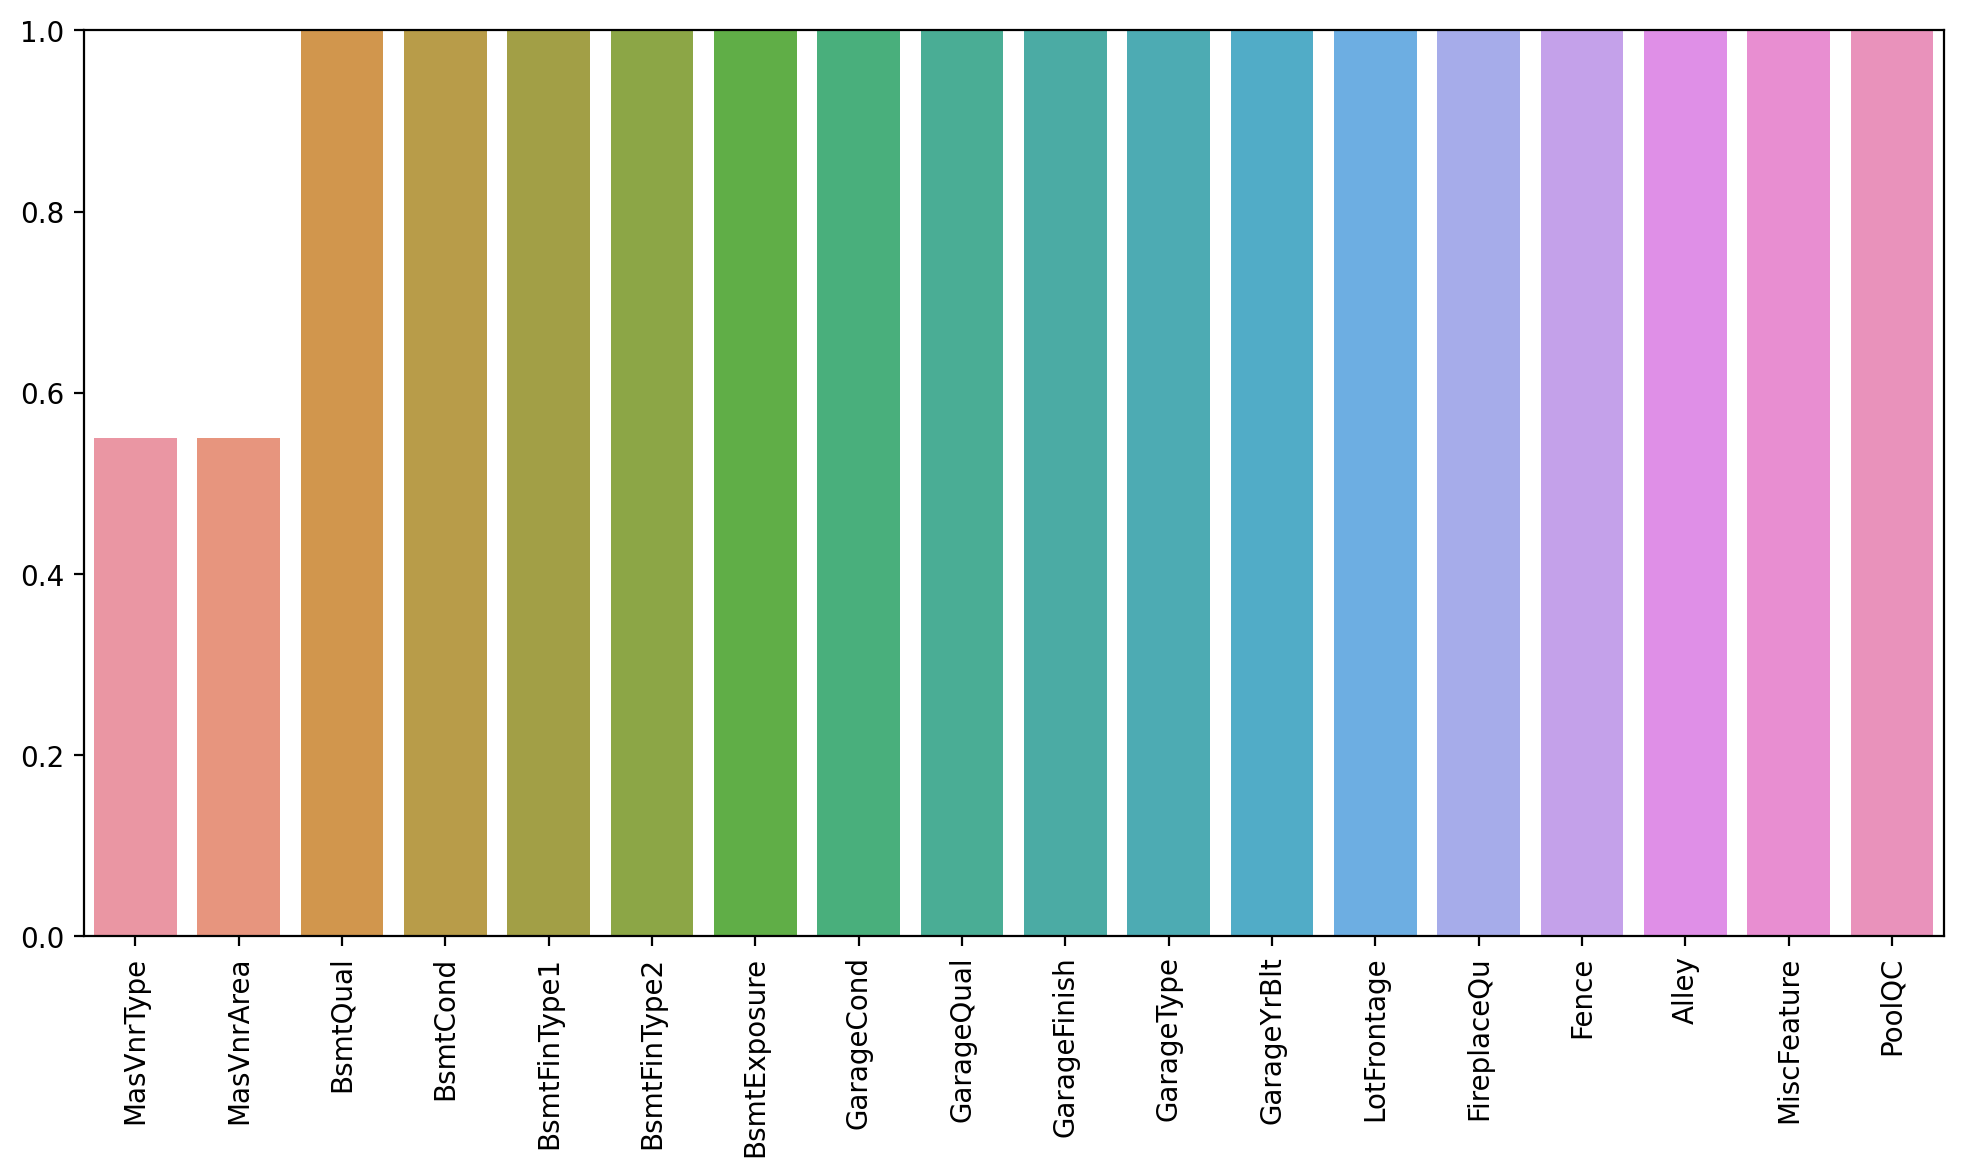

In [29]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)
#Set 1% threshold:
plt.ylim(0,1)

<h3>filling a missing Data with 0 for integer feature and None for object one:</h3>

In [30]:
df['MasVnrType']= df['MasVnrType'].fillna('None')
df['MasVnrArea']= df['MasVnrArea'].fillna(0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'BsmtQual'),
  Text(1, 0, 'BsmtCond'),
  Text(2, 0, 'BsmtFinType1'),
  Text(3, 0, 'BsmtExposure'),
  Text(4, 0, 'BsmtFinType2'),
  Text(5, 0, 'GarageType'),
  Text(6, 0, 'GarageYrBlt'),
  Text(7, 0, 'GarageFinish'),
  Text(8, 0, 'GarageQual'),
  Text(9, 0, 'GarageCond'),
  Text(10, 0, 'LotFrontage'),
  Text(11, 0, 'FireplaceQu'),
  Text(12, 0, 'Fence'),
  Text(13, 0, 'Alley'),
  Text(14, 0, 'MiscFeature'),
  Text(15, 0, 'PoolQC')])

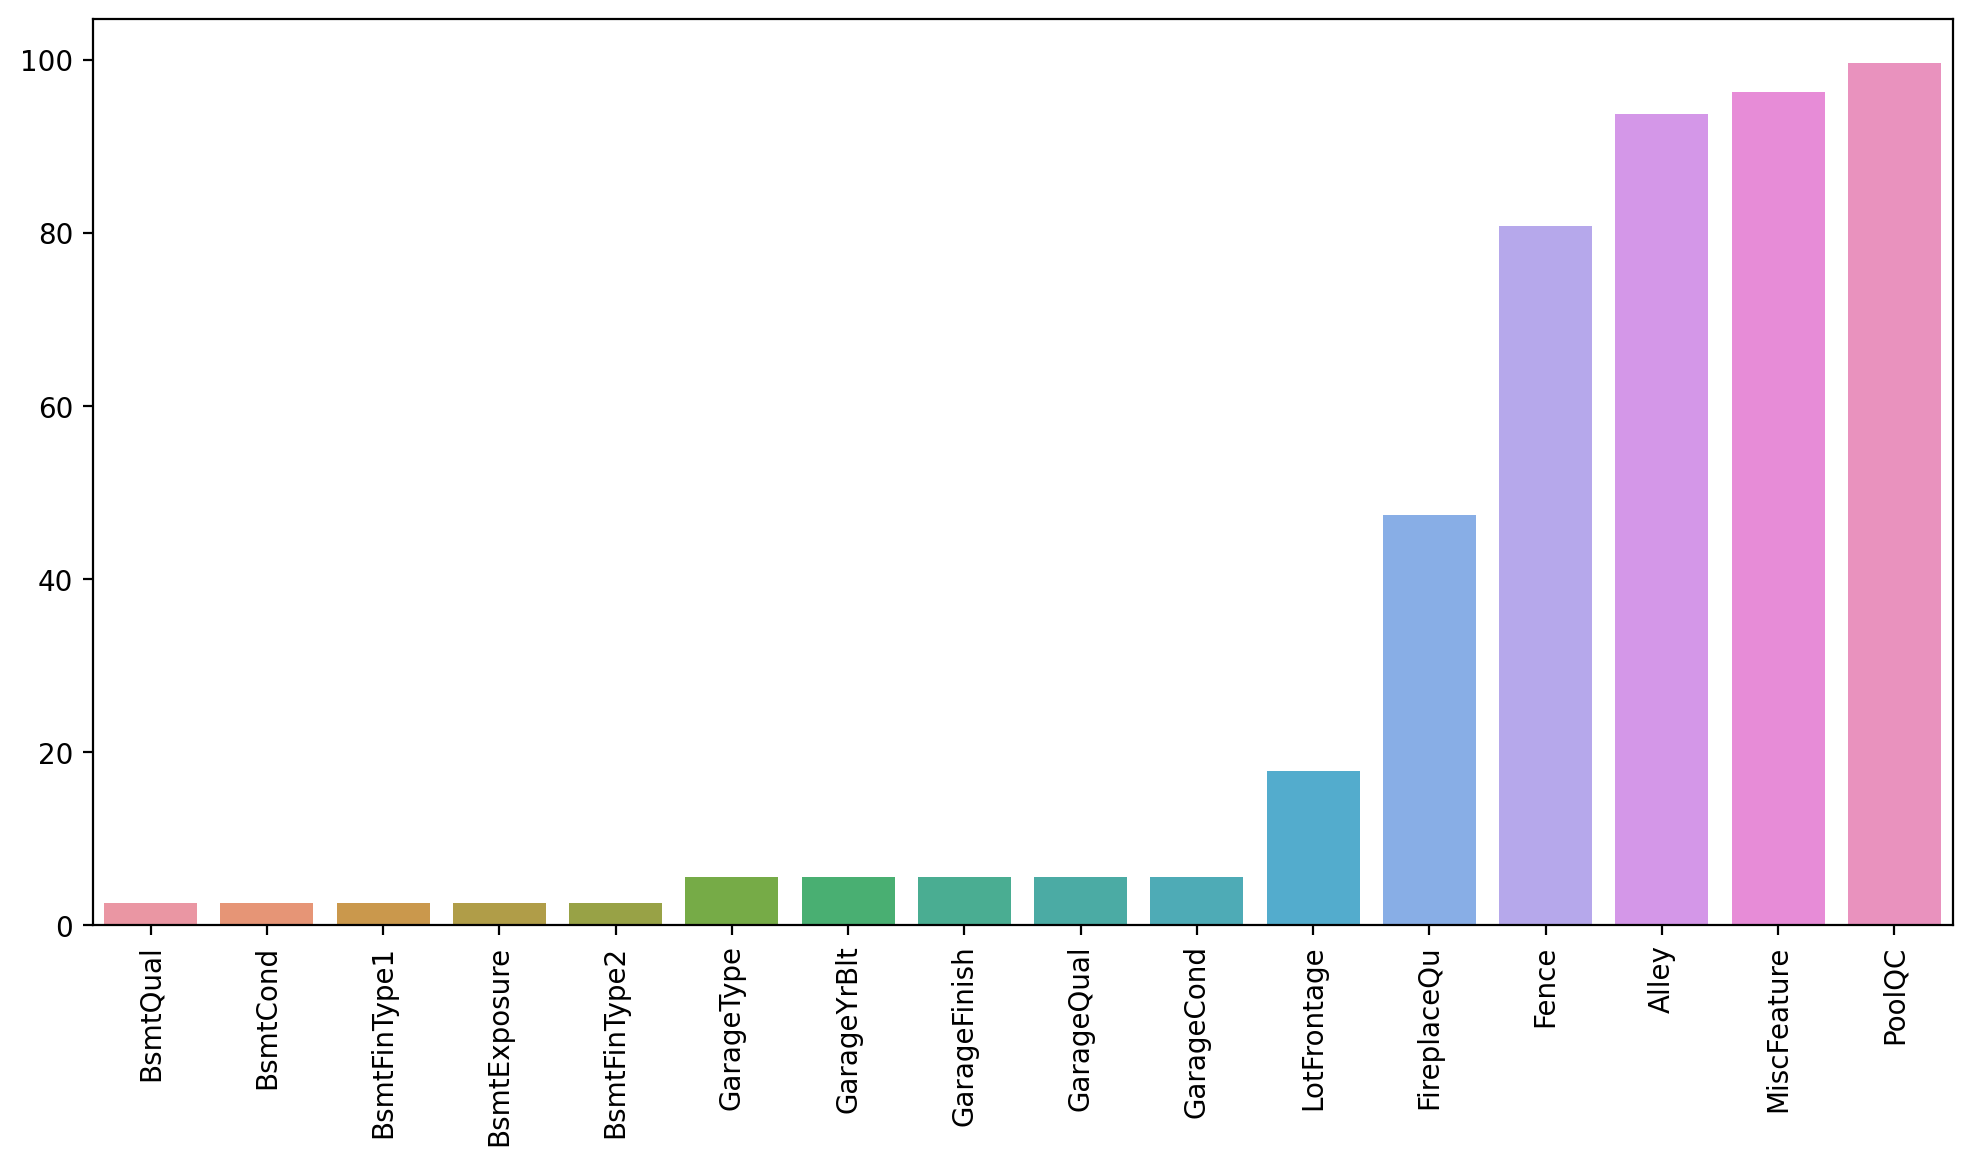

In [31]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

In [32]:
bsm=['BsmtQual','BsmtCond','BsmtFinType1','BsmtExposure','BsmtFinType2']
for i in bsm:
    print(type(i))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [33]:
df[bsm]=df[bsm].fillna('None')


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'GarageType'),
  Text(1, 0, 'GarageYrBlt'),
  Text(2, 0, 'GarageFinish'),
  Text(3, 0, 'GarageQual'),
  Text(4, 0, 'GarageCond'),
  Text(5, 0, 'LotFrontage'),
  Text(6, 0, 'FireplaceQu'),
  Text(7, 0, 'Fence'),
  Text(8, 0, 'Alley'),
  Text(9, 0, 'MiscFeature'),
  Text(10, 0, 'PoolQC')])

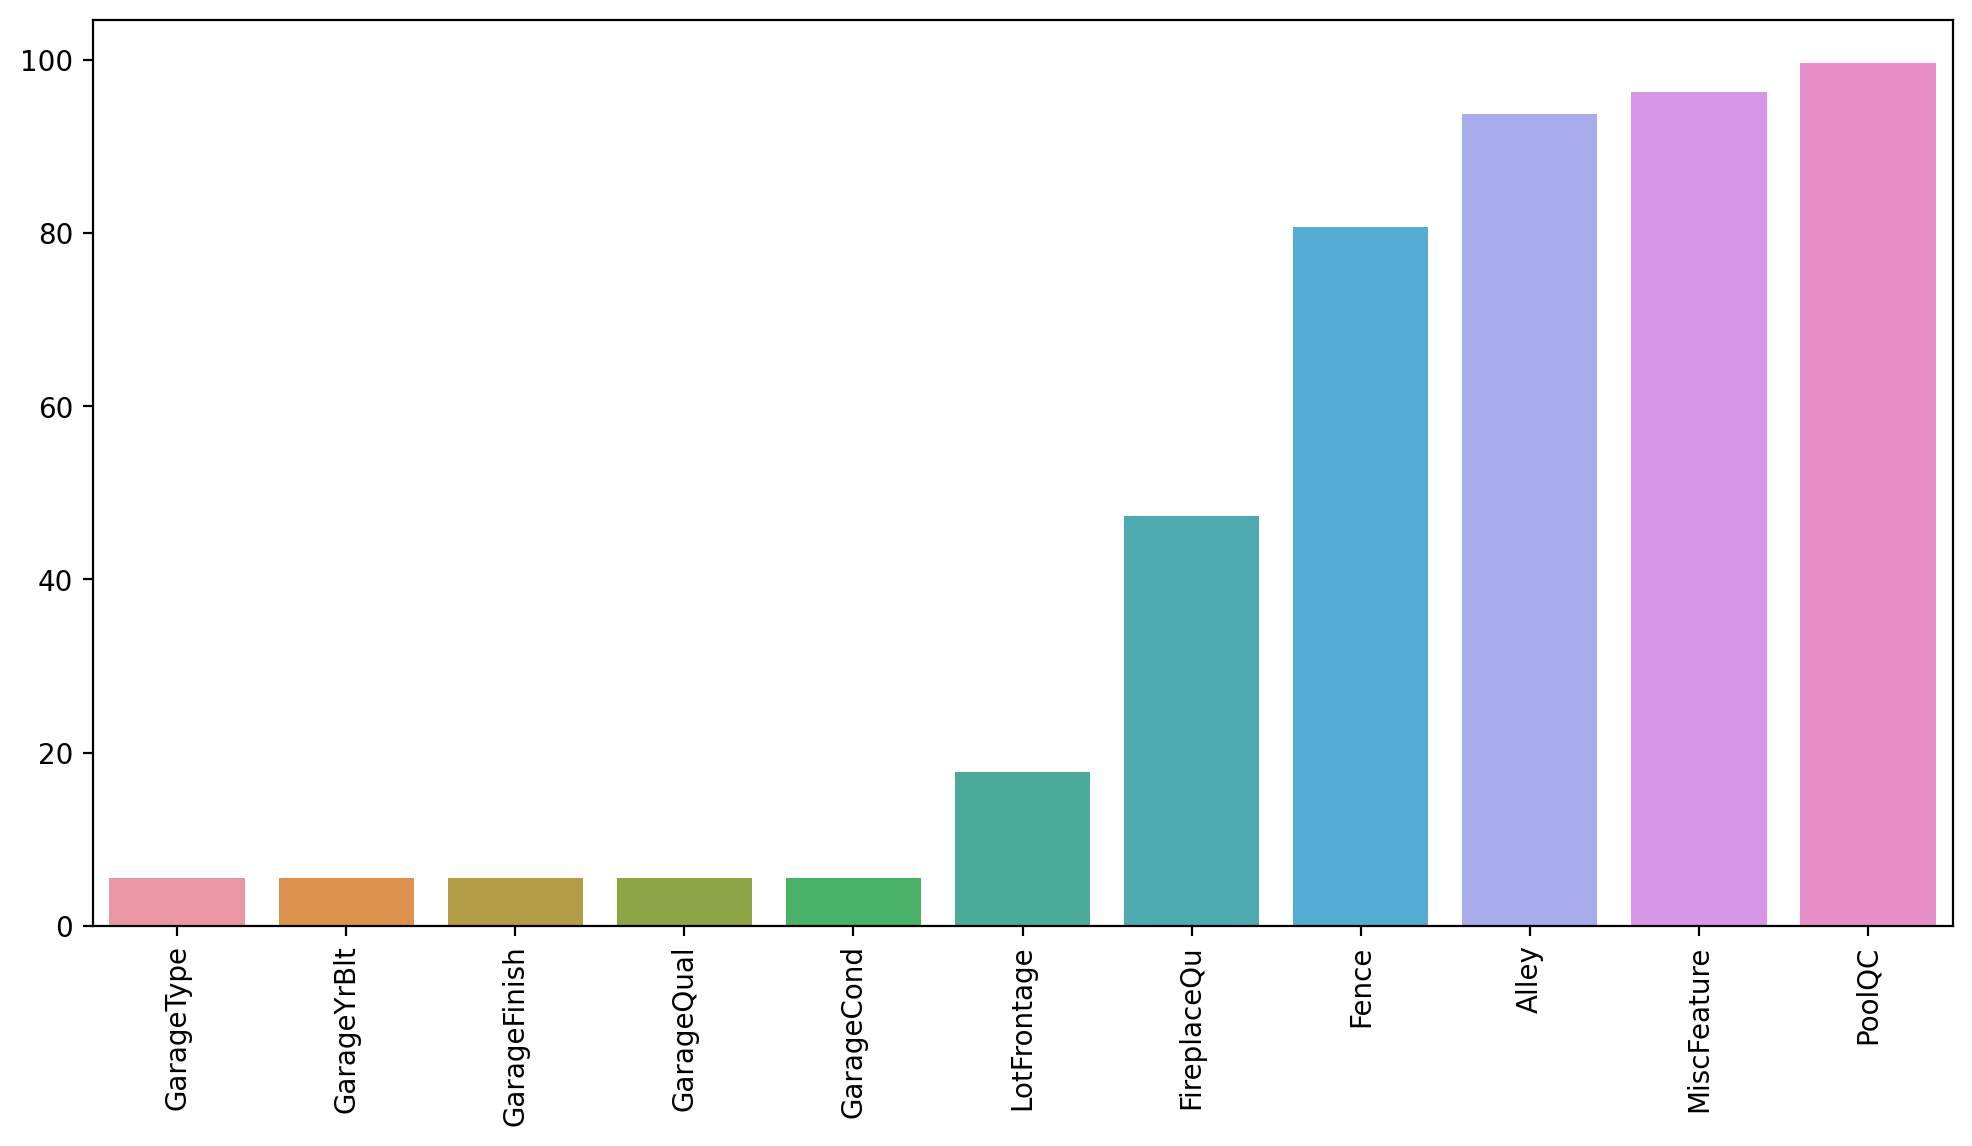

In [34]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

In [35]:
garage=['GarageType','GarageFinish','GarageQual','GarageCond']
df[garage]=df[garage].fillna('None')

<h3>replace the amount of missing Data with mean of the GarageYrBlt:</h3>

In [36]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(value=df['GarageYrBlt'].mean())

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'LotFrontage'),
  Text(1, 0, 'FireplaceQu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'MiscFeature'),
  Text(5, 0, 'PoolQC')])

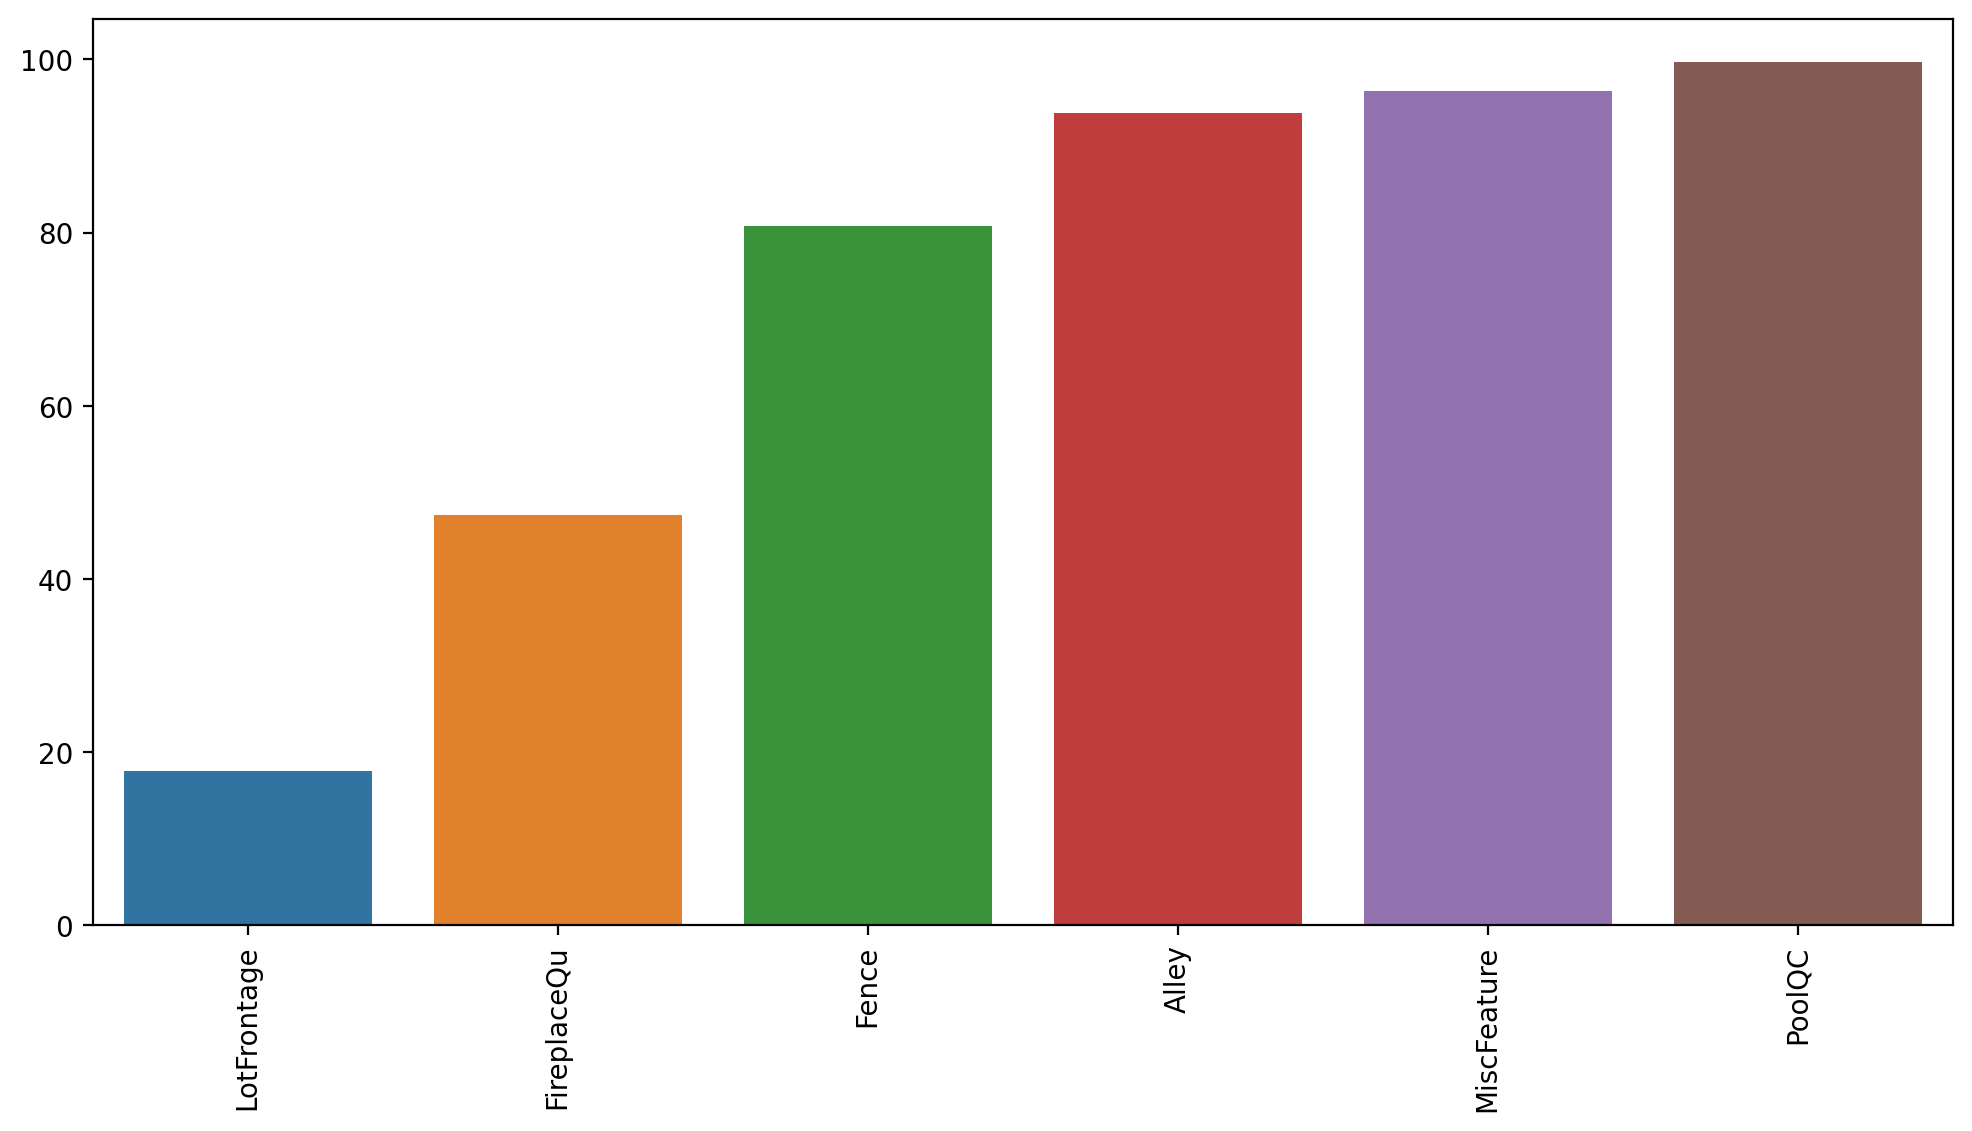

In [37]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

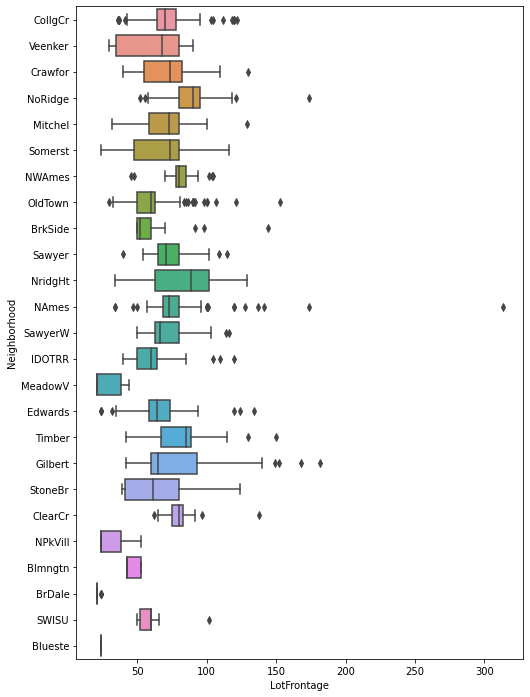

In [38]:
plt.figure(figsize=(8,12))
sns.boxplot(data=df, x='LotFrontage', y='Neighborhood')

In [39]:
df.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.682540
Crawfor    71.804878
Edwards    64.811111
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    89.290323
NridgHt    81.881579
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.500000
Somerst    64.666667
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [40]:
df['LotFrontage']=df.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'FireplaceQu'),
  Text(1, 0, 'Fence'),
  Text(2, 0, 'Alley'),
  Text(3, 0, 'MiscFeature'),
  Text(4, 0, 'PoolQC')])

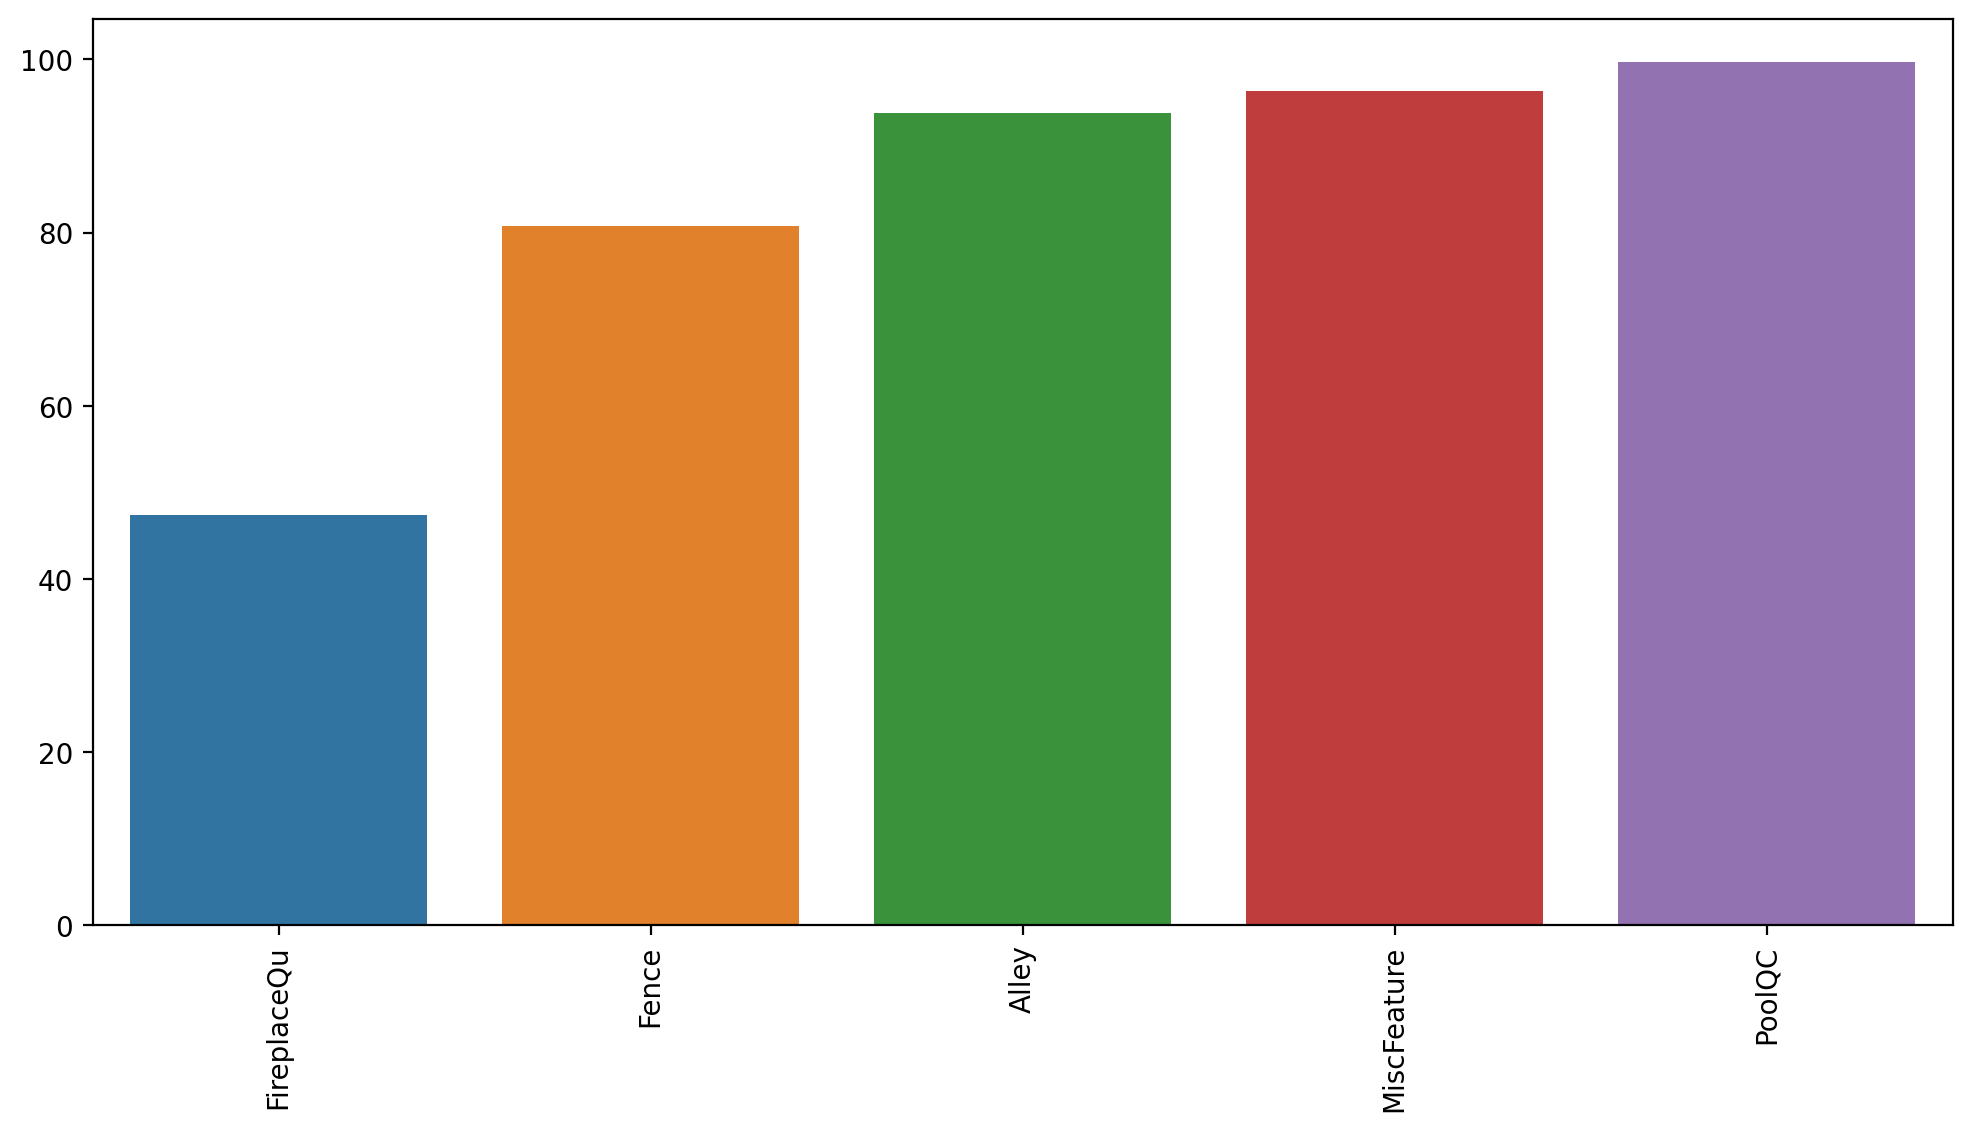

In [41]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

In [42]:
df['FireplaceQu']= df['FireplaceQu'].fillna('None')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Fence'),
  Text(1, 0, 'Alley'),
  Text(2, 0, 'MiscFeature'),
  Text(3, 0, 'PoolQC')])

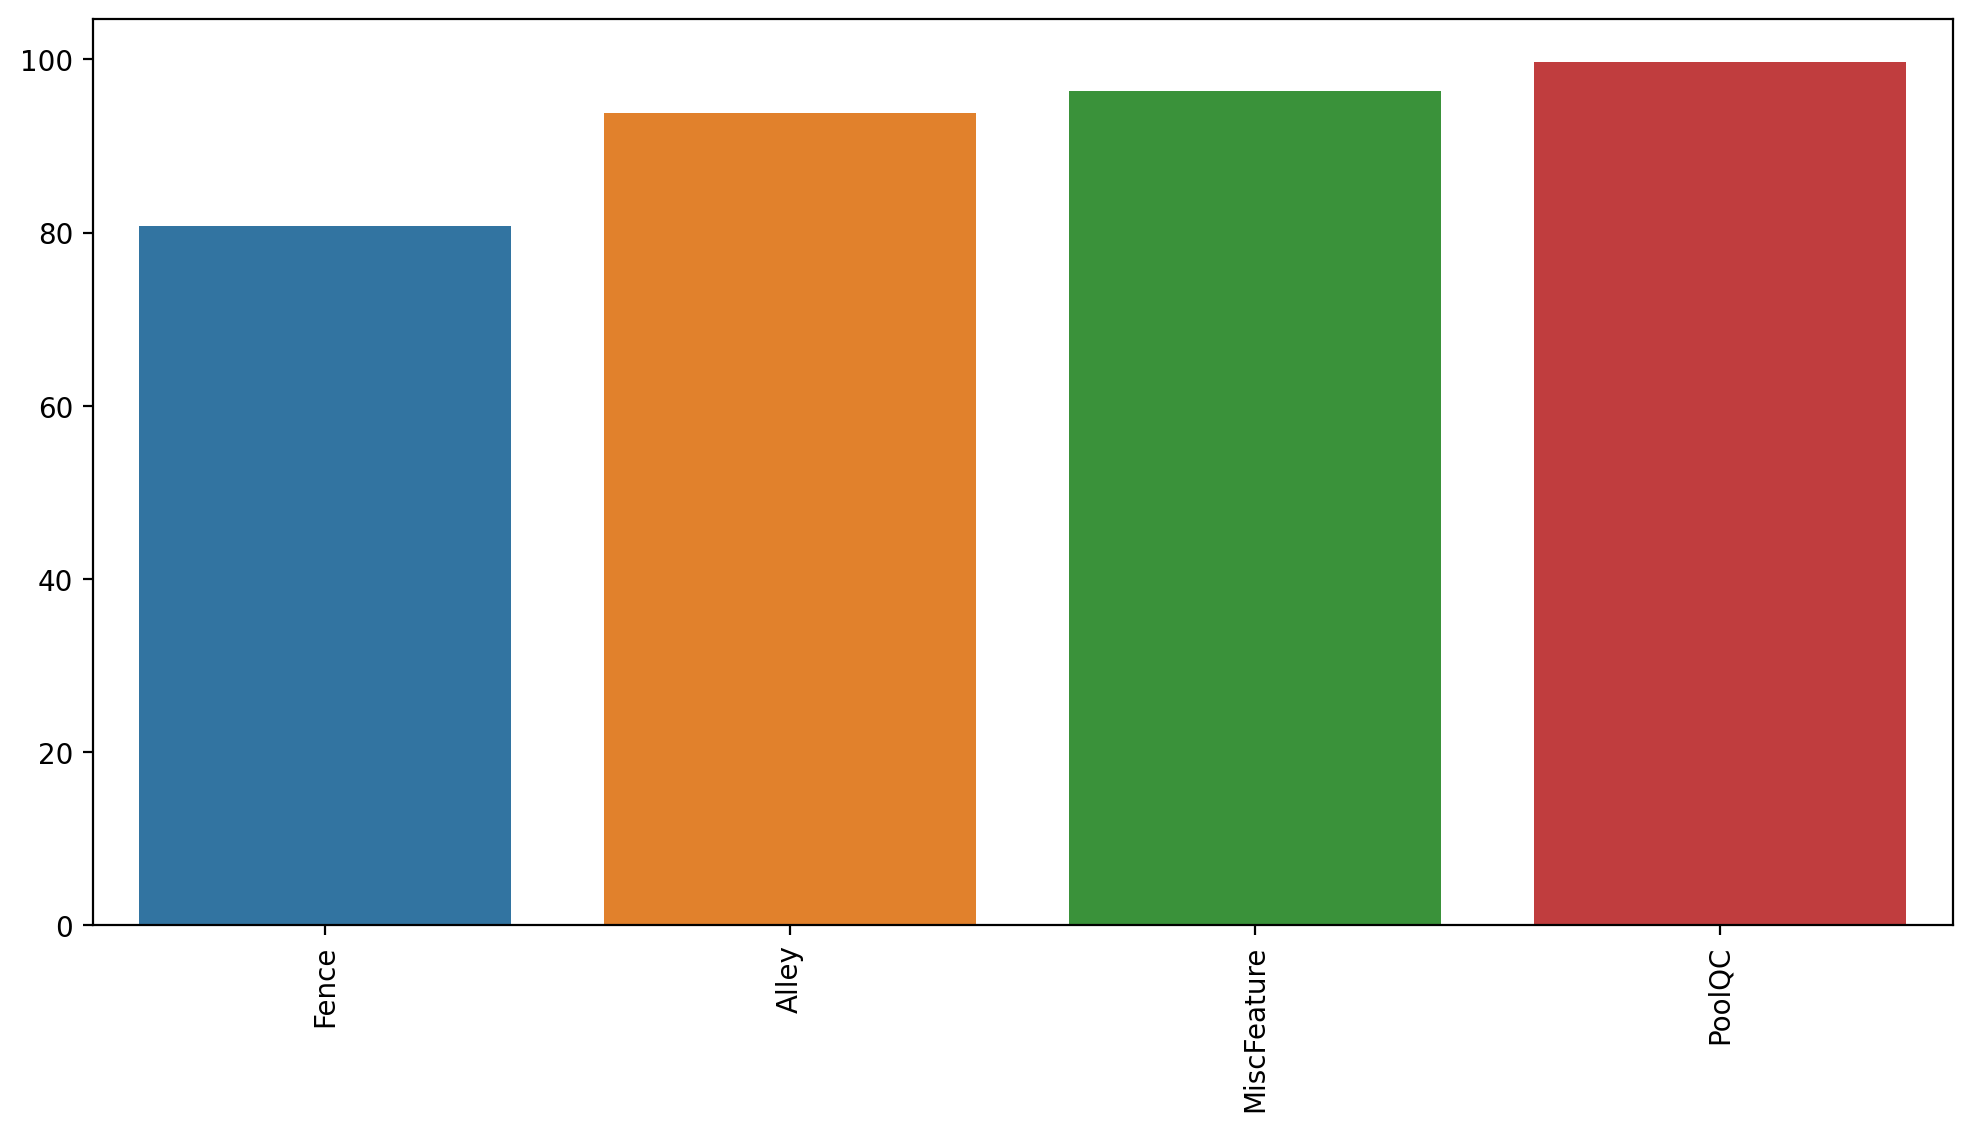

In [43]:
nan_percent= missing_percent(df)
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)

In [44]:
df=df.drop(['Fence','Alley','MiscFeature','PoolQC'],axis=1)

In [45]:
nan_percent= missing_percent(df)
nan_percent

Series([], dtype: float64)

<b>There is no more missing Data</b>

<h3>Dealing with Categorical Data</h3


<h3>Changing Numerical Columns to Categorical</h3>

In [46]:
df['MSSubClass']

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1455, dtype: int64

In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1455 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1455 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1455 non-null   float64
 3   LotArea        1455 non-null   int64  
 4   Street         1455 non-null   object 
 5   LotShape       1455 non-null   object 
 6   LandContour    1455 non-null   object 
 7   Utilities      1455 non-null   object 
 8   LotConfig      1455 non-null   object 
 9   LandSlope      1455 non-null   object 
 10  Neighborhood   1455 non-null   object 
 11  Condition1     1455 non-null   object 
 12  Condition2     1455 non-null   object 
 13  BldgType       1455 non-null   object 
 14  HouseStyle     1455 non-null   object 
 15  OverallQual    1455 non-null   int64  
 16  OverallCond    1455 non-null   int64  
 17  YearBuilt      1455 non-null   int64  
 18  YearRemo

In [48]:
df['MSSubClass'].unique()

array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

<h3>Convert to String:</h3>

In [49]:
df['MSSubClass']= df['MSSubClass'].apply(str)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1455 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1455 non-null   object 
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1455 non-null   float64
 3   LotArea        1455 non-null   int64  
 4   Street         1455 non-null   object 
 5   LotShape       1455 non-null   object 
 6   LandContour    1455 non-null   object 
 7   Utilities      1455 non-null   object 
 8   LotConfig      1455 non-null   object 
 9   LandSlope      1455 non-null   object 
 10  Neighborhood   1455 non-null   object 
 11  Condition1     1455 non-null   object 
 12  Condition2     1455 non-null   object 
 13  BldgType       1455 non-null   object 
 14  HouseStyle     1455 non-null   object 
 15  OverallQual    1455 non-null   int64  
 16  OverallCond    1455 non-null   int64  
 17  YearBuilt      1455 non-null   int64  
 18  YearRemo

<h3> Creating Dummy Variables:</h3>


In [51]:
df.select_dtypes(include='object')

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [52]:
df_num= df.select_dtypes(exclude='object')
df_obj= df.select_dtypes(include='object')

In [53]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1455 entries, 0 to 1459
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1455 non-null   float64
 1   LotArea        1455 non-null   int64  
 2   OverallQual    1455 non-null   int64  
 3   OverallCond    1455 non-null   int64  
 4   YearBuilt      1455 non-null   int64  
 5   YearRemodAdd   1455 non-null   int64  
 6   MasVnrArea     1455 non-null   float64
 7   BsmtFinSF1     1455 non-null   int64  
 8   BsmtFinSF2     1455 non-null   int64  
 9   BsmtUnfSF      1455 non-null   int64  
 10  TotalBsmtSF    1455 non-null   int64  
 11  1stFlrSF       1455 non-null   int64  
 12  2ndFlrSF       1455 non-null   int64  
 13  LowQualFinSF   1455 non-null   int64  
 14  GrLivArea      1455 non-null   int64  
 15  BsmtFullBath   1455 non-null   int64  
 16  BsmtHalfBath   1455 non-null   int64  
 17  FullBath       1455 non-null   int64  
 18  HalfBath

In [54]:
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1455 entries, 0 to 1459
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1455 non-null   object
 1   MSZoning       1455 non-null   object
 2   Street         1455 non-null   object
 3   LotShape       1455 non-null   object
 4   LandContour    1455 non-null   object
 5   Utilities      1455 non-null   object
 6   LotConfig      1455 non-null   object
 7   LandSlope      1455 non-null   object
 8   Neighborhood   1455 non-null   object
 9   Condition1     1455 non-null   object
 10  Condition2     1455 non-null   object
 11  BldgType       1455 non-null   object
 12  HouseStyle     1455 non-null   object
 13  RoofStyle      1455 non-null   object
 14  RoofMatl       1455 non-null   object
 15  Exterior1st    1455 non-null   object
 16  Exterior2nd    1455 non-null   object
 17  MasVnrType     1455 non-null   object
 18  ExterQual      1455 non-null

In [55]:
# Converting:
df_obj= pd.get_dummies(df_obj, drop_first=True)

In [56]:
df_obj.shape

(1455, 223)

In [57]:
Final_df= pd.concat([df_num, df_obj], axis=1)
Final_df.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,0,0,0,0,1,0,0,0,1,0


#### Now, the Dataset is Ready for any Machine Learing Model & Analysis

<a id="Lin"></a>
# Linear Regression model

In [58]:
Final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1455 entries, 0 to 1459
Columns: 259 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(3), int64(33), uint8(223)
memory usage: 769.7 KB


<Figure size 864x432 with 0 Axes>

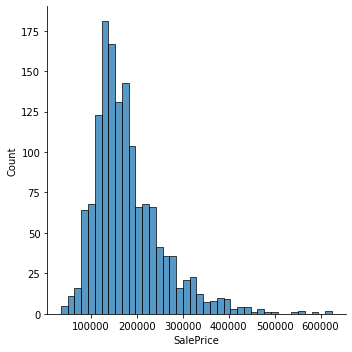

<Figure size 864x432 with 0 Axes>

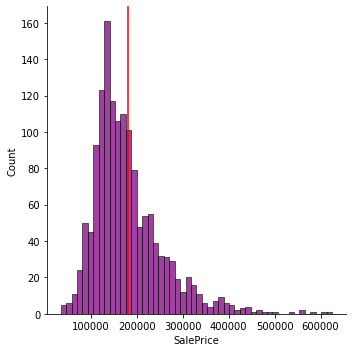

In [59]:
from scipy.stats import norm
plt.figure(figsize=(12,6))
sns.displot(Final_df['SalePrice'])
plt.figure(figsize=(12,6))
sns.displot(Final_df['SalePrice'],color='purple',bins=50)
plt.axvline(x=(Final_df['SalePrice'].mean()), color='r')

<h3>We need to make this normal distributed.</h3>

In [60]:
Final_df['SalePrice'] = np.log1p(Final_df['SalePrice'])

<Figure size 864x432 with 0 Axes>

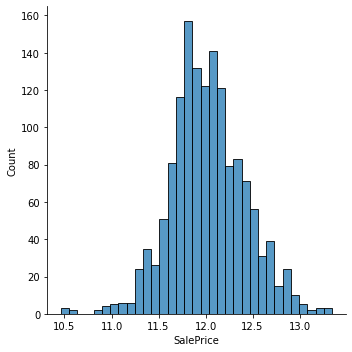

<Figure size 864x432 with 0 Axes>

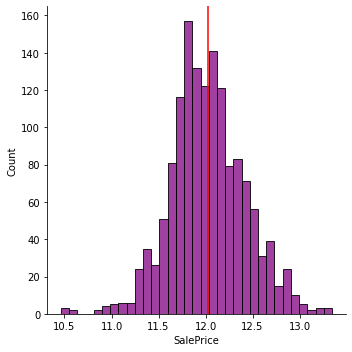

In [61]:
from scipy.stats import norm
plt.figure(figsize=(12,6))
sns.displot(Final_df['SalePrice'])
plt.figure(figsize=(12,6))
sns.displot(Final_df['SalePrice'],color='purple')
plt.axvline(x=(Final_df['SalePrice'].mean()), color='r')

<h3>Determine the Features & Target Variable</h3>

In [62]:
X=Final_df.drop('SalePrice',axis=1)
y=Final_df['SalePrice']

<h3>Split the Dataset to Train & Test</h3>

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

<h3>Train the Model</h3>


In [64]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
pd.DataFrame(model.coef_ , X.columns ,columns=['coefcient'])

,coefcient
LotFrontage,0.000277
LotArea,0.000004
OverallQual,0.035778
OverallCond,0.044030
YearBuilt,0.002089
...,...
SaleCondition_AdjLand,0.092963
SaleCondition_Alloca,0.021960
SaleCondition_Family,0.007768
SaleCondition_Normal,0.063990


<h3>predicting Test Data</h3>

In [65]:
y_pred= model.predict(X_test)
pd.DataFrame({'Y_Test': y_test,'Y_Pred':y_pred})[:5]

,Y_Test,Y_Pred
18,11.976666,11.927168
104,12.040614,11.906941
373,11.719948,11.750520
1227,11.898195,11.970252
342,11.379406,11.331570


<h3>Evaluating the Model</h3>


In [66]:
from sklearn import metrics
MAE_linear=metrics.mean_absolute_error(y_test , y_pred)
MSE_linear=metrics.mean_squared_error(y_test , y_pred)
RMSE_linear=np.sqrt(MSE_linear)
pd.DataFrame([MAE_linear,MSE_linear,RMSE_linear], index=['MAE_linear','MSE_linear','RMSE_linear'],columns=['Quantity'])


,Quantity
MAE_linear,0.089358
MSE_linear,0.017944
RMSE_linear,0.133957


<h3>Residuals:</h3>


Text(0.5, 1.0, 'bias of y')

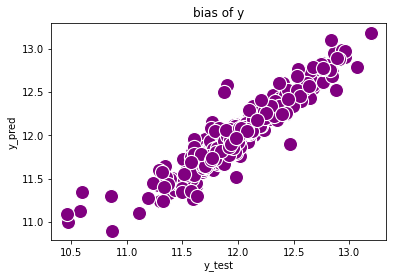

In [67]:

test_residual=y_test-y_pred
sns.scatterplot(x=y_test,y=y_pred,color='purple' ,s=200)
plt.ylabel('y_pred')
plt.xlabel('y_test')
plt.title('bias of y')

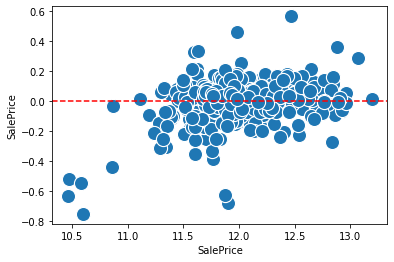

In [68]:
sns.scatterplot(x=y_test,y=test_residual,s=200)
plt.axhline(y=0,color='red',ls='--')

<h3> As we see ,the residuals show a clear pattern.so we can say,linear regression is not suitable for this model.</h3>

<a id="Pol"></a>
# Polynomial Regression model

<h3>Determine the Features & Target Variable</h3>

In [69]:
X=Final_df.drop('SalePrice',axis=1)
y=Final_df['SalePrice']

<h3> Preprocessing</h3>


In [70]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2, include_bias=False)
poly_features=polynomial_converter.fit(X)
poly_features=polynomial_converter.transform(X)


<h3>Split the Data to Train & Test</h3>

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

<h3> Train the Model</h3>


In [72]:
from sklearn.linear_model import LinearRegression
polymodel=LinearRegression()
polymodel.fit(X_train, y_train)

LinearRegression()

<h3> Predicting Test Data</h3>


In [73]:
y_pred=polymodel.predict(X_test)
pd.DataFrame({'Y_Test': y_test,'Y_Pred':y_pred, 'Residuals':(y_test-y_pred) }).head(5)


,Y_Test,Y_Pred,Residuals
18,11.976666,12.078583,-0.101917
104,12.040614,12.463778,-0.423164
373,11.719948,12.012883,-0.292935
1227,11.898195,11.872688,0.025507
342,11.379406,11.458916,-0.079510


<h3> Evaluating the Model</h3>

In [74]:
from sklearn import metrics
MAE_Poly = metrics.mean_absolute_error(y_test,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test,y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)

pd.DataFrame([MAE_Poly, MSE_Poly, RMSE_Poly], index=['MAE_Poly', 'MSE_Poly', 'RMSE_Poly'], columns=['metrics'])


,metrics
MAE_Poly,0.308848
MSE_Poly,1.124904
RMSE_Poly,1.060615


In [75]:
del df

In [76]:
# Adjusting Model Parameters
# Train List of RMSE per degree
train_RMSE_list=[]
#Test List of RMSE per degree
test_RMSE_list=[]

for d in range(1,3):
    
    #Preprocessing
    #create poly data set for degree (d)
    polynomial_converter= PolynomialFeatures(degree=d, include_bias=False)
    poly_features= polynomial_converter.fit(X)
    poly_features= polynomial_converter.transform(X)
    
    #Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    #Train the Model
    polymodel=LinearRegression()
    polymodel.fit(X_train, y_train)
    
    #Predicting on both Train & Test Data
    y_train_pred=polymodel.predict(X_train)
    y_test_pred=polymodel.predict(X_test)
    
    #Evaluating the Model
    
    #RMSE of Train set
    train_RMSE=np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
    
    #RMSE of Test Set
    test_RMSE=np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
      #Append the RMSE to the Train and Test List
    
    train_RMSE_list.append(train_RMSE)
    test_RMSE_list.append(test_RMSE)

In [77]:
pd.DataFrame({'train_RMSE_list': train_RMSE_list,'test_RMSE_list':test_RMSE_list})

,train_RMSE_list,test_RMSE_list
0,8.373066e-02,0.133957
1,6.192005e-12,1.060615


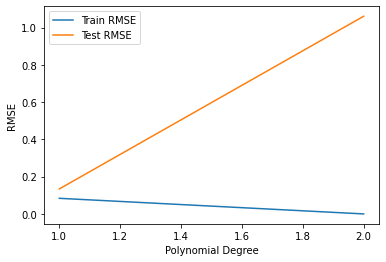

In [78]:
#**Plot the Polynomial degree VS RMSE**

plt.plot(range(1,3), train_RMSE_list[:13], label='Train RMSE')
plt.plot(range(1,3), test_RMSE_list[:13], label='Test RMSE')

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()

<h3>It shows polynomial can't help to redious errores</h3>

<a id="Reg"></a>
# Regularization:


<h4>Preprocessing</h4>

In [79]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter= PolynomialFeatures(degree=1, include_bias=False)
poly_features= polynomial_converter.fit_transform(X)

<h4>Split the Data to Train & Test</h4>

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

<h4>Scaling the Data</h4>

In [81]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)
X_train= scaler.transform(X_train)
X_test= scaler.transform(X_test)

<a id="Ridge"></a>
# Ridge 


<h4>Train the Model</h4>

In [82]:
from sklearn.linear_model import Ridge
ridge_model= Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

Ridge(alpha=10)

<h4>predict Test Data</h4>

In [83]:
y_pred= ridge_model.predict(X_test)

<h4>Evaluating the Model</h4>

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE_Ridge= mean_absolute_error(y_test, y_pred)
MSE_Ridge= mean_squared_error(y_test, y_pred)
RMSE_Ridge= np.sqrt(MSE_Ridge)
pd.DataFrame([MAE_Ridge, MSE_Ridge, RMSE_Ridge], index=['MAE_Ridge', 'MSE_Ridge', 'RMSE_Ridge'], columns=['metrics'])

,metrics
MAE_Ridge,0.087600
MSE_Ridge,0.017781
RMSE_Ridge,0.133344


<h4>Coosing an alpha value with Cross-Validation</h4>

<h4>Train the Model</h4>

In [85]:
from sklearn.linear_model import RidgeCV
ridge_cv_model=RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')
ridge_cv_model.fit(X_train, y_train)

RidgeCV(alphas=array([ 0.1,  1. , 10. ]), scoring='neg_mean_absolute_error')

In [86]:
ridge_cv_model.alpha_

10.0

<h4>Predicting Test Data</h4>

In [87]:
y_pred_ridge= ridge_cv_model.predict(X_test)

In [88]:
MAE_ridge= mean_absolute_error(y_test, y_pred_ridge)
MSE_ridge= mean_squared_error(y_test, y_pred_ridge)
RMSE_ridge= np.sqrt(MSE_ridge)
pd.DataFrame([MAE_ridge, MSE_ridge, RMSE_ridge], index=['MAE_ridge_CV', 'MSE_ridge_CV', 'RMSE_ridge_CV'], columns=['Ridge Metrics'])

,Ridge Metrics
MAE_ridge_CV,0.087600
MSE_ridge_CV,0.017781
RMSE_ridge_CV,0.133344


In [89]:
ridge_cv_model.coef_

array([ 5.94030123e-03,  2.93648448e-02,  5.05861486e-02,  4.66203084e-02,
        5.70186019e-02,  1.38060497e-02,  9.38486150e-03,  2.68387806e-02,
        7.76487287e-03,  4.11645771e-03,  3.54942953e-02,  3.83347722e-02,
        4.42966081e-02,  3.21025404e-03,  6.72011775e-02,  1.40750576e-02,
       -9.66728801e-04,  1.60381563e-02,  1.51793693e-02, -4.36926399e-04,
       -2.25427139e-02,  3.78567353e-03,  9.19391155e-03, -3.99629085e-03,
        2.23156252e-02,  1.59162739e-02,  1.11222567e-02,  9.44493440e-03,
        4.46742884e-03,  3.54908802e-03,  1.06498540e-02,  6.61803571e-03,
        8.38445751e-04, -4.74787960e-03, -4.36865209e-03, -1.61695379e-02,
       -4.70910314e-03,  1.39877255e-02,  6.75133663e-03, -8.07627174e-03,
       -8.96618682e-04, -1.08121459e-02, -6.17774778e-03, -1.23014282e-03,
        1.74644768e-02,  1.31100600e-03, -1.18596818e-02,  2.26408452e-03,
        6.90262860e-03,  2.47535250e-02,  1.13660394e-02,  4.58846706e-02,
        1.74855757e-02,  

<a id="Lasso"></a>
# Lasso


In [90]:
from sklearn.linear_model import LassoCV
lasso_cv_model= LassoCV(eps=0.01, n_alphas=100, cv=5)
lasso_cv_model.fit(X_train, y_train)

LassoCV(cv=5, eps=0.01)

In [91]:
lasso_cv_model.alpha_

0.004085274904584574

In [92]:
y_pred_lasso= lasso_cv_model.predict(X_test)
MAE_Lasso= mean_absolute_error(y_test, y_pred_lasso)
MSE_Lasso= mean_squared_error(y_test, y_pred_lasso)
RMSE_Lasso= np.sqrt(MSE_Lasso)

In [93]:
pd.DataFrame([MAE_Lasso, MSE_Lasso, RMSE_Lasso], index=['MAE_Lasso', 'MSE_Lasso', 'RMSE_Lasso'], columns=['Lasso Metrics'])

,Lasso Metrics
MAE_Lasso,0.086358
MSE_Lasso,0.016896
RMSE_Lasso,0.129986


In [94]:
lasso_cv_model.coef_

array([ 1.05110275e-02,  1.61724900e-02,  7.70890760e-02,  4.45831623e-02,
        6.26358210e-02,  1.29609220e-02,  5.17065994e-03,  2.63560619e-02,
        0.00000000e+00, -0.00000000e+00,  4.19547674e-02,  3.15720823e-03,
        0.00000000e+00, -6.08863853e-04,  1.29782831e-01,  1.22867413e-02,
       -0.00000000e+00,  2.37671375e-03,  5.00896243e-03, -0.00000000e+00,
       -1.34579207e-02,  0.00000000e+00,  8.99532744e-03,  0.00000000e+00,
        2.83523193e-02,  1.25986519e-02,  6.74093301e-03,  9.69337823e-03,
        0.00000000e+00,  0.00000000e+00,  5.65836574e-03,  1.16493636e-03,
       -0.00000000e+00, -0.00000000e+00, -5.48296549e-04, -1.04705358e-02,
       -0.00000000e+00, -0.00000000e+00,  0.00000000e+00, -6.16468201e-03,
       -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        6.69764094e-03, -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  3.92440942e-03,
       -1.82255211e-02,  

<a id="Elas"></a>
# Elastic Net


In [95]:
from sklearn.linear_model import ElasticNetCV
elastic_model= ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1],cv=5, max_iter=100000)
elastic_model.fit(X_train, y_train)

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1],
             max_iter=100000)

In [96]:
elastic_model.l1_ratio_

0.5

In [97]:
y_pred_elastic=elastic_model.predict(X_test)

In [98]:
MAE_Elastic= mean_absolute_error(y_test, y_pred_elastic)
MSE_Elastic= mean_squared_error(y_test, y_pred_elastic)
RMSE_Elastic= np.sqrt(MSE_Elastic)

In [99]:
pd.DataFrame([MAE_Elastic, MSE_Elastic, RMSE_Elastic], index=['MAE_Elastic', 'MSE_Elastic', 'RMSE_Elastic'], columns=['Elastic Metrics'])

,Elastic Metrics
MAE_Elastic,0.086337
MSE_Elastic,0.016874
RMSE_Elastic,0.129898


In [100]:
elastic_model.coef_

array([ 1.07464679e-02,  1.60716858e-02,  7.65496667e-02,  4.40783199e-02,
        6.00524234e-02,  1.31678758e-02,  5.65511821e-03,  2.61373067e-02,
        0.00000000e+00, -0.00000000e+00,  4.13659190e-02,  4.77886523e-03,
        0.00000000e+00, -5.18718917e-04,  1.26661763e-01,  1.23455702e-02,
       -0.00000000e+00,  3.92443937e-03,  6.40376277e-03,  0.00000000e+00,
       -1.33885762e-02,  0.00000000e+00,  9.02572821e-03,  0.00000000e+00,
        2.78156788e-02,  1.31858012e-02,  6.91730372e-03,  9.91748040e-03,
        0.00000000e+00,  0.00000000e+00,  5.74373861e-03,  1.34453209e-03,
       -0.00000000e+00, -0.00000000e+00, -7.38546960e-04, -1.03918616e-02,
       -0.00000000e+00, -0.00000000e+00,  0.00000000e+00, -6.62449957e-03,
       -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        6.86378415e-03, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  4.27200437e-03,
       -1.77604338e-02,  